## EGU 2026 Talk
Notebook to create figures used in my talk for EGU 2026.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datatree import DataTree, open_datatree
import xskillscore
import matplotlib.colors as mcolors
import cartopy.crs as ccrs

from isca_tools import plot
from isca_tools.plot import fig_resize, colored_line, update_linewidth, update_fontsize, savefig
from isca_tools.utils.fourier import coef_conversion
from isca_tools.utils.xarray import convert_ds_dtypes, update_dim_slice
from pathlib import Path
import os
import warnings
from glob import glob
from tqdm.notebook import tqdm

from isca_tools.utils.moist_physics import sphum_sat
import jobs.thesis_season.thesis_figs.utils as utils
from jobs.era5.surface_flux.av_annual_cycle.hysteresis_check_get_data import get_rh

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

## Single Coordinate Plots
### Load all data at the single coordinate

In [2]:
data_dir = f'/Users/joshduffield/Documents/StAndrews/Isca/jobs/era5/surface_flux/av_annual_cycle/output_20years/'
ds = xr.open_mfdataset(f'{data_dir}/*.nc')
lat_single = 38
lon_single = 150
ds_single = ds.sel(latitude=lat_single, longitude=lon_single)
ds_single['net_up_flux'] = -ds_single.mslhf - ds_single.msshf - ds_single.msnlwrf
ds_single['w_atm'] = np.sqrt(ds_single['u10'] ** 2 + ds_single['v10'] ** 2)
ds_single['rh_atm'] = get_rh(ds_single.d2m, ds_single.t2m, ds_single.sp)
ds_single['t_dq'] = ds_single.skt - ds_single.t2m
ds_single = ds_single.drop_vars(['u10', 'v10', 'sp', 'd2m', 't2m'])
ds_single = ds_single.load()

# Expand out to new dimensions accounting for the different fitting metrics.
fit_method = xr.DataArray(['simulated', 'direct', 'linear', 'linear_phase'], name='fit_method',
                          dims='fit_method')
fit_method = fit_method.assign_coords(fit_method=fit_method.values)
ds_single = ds_single.expand_dims(fit_method=fit_method)

## Compute Fitting of all variables
Below I compute the annual harmonic and then empirical estimates of all the variables loaded in.

In [3]:
for key in ds_single:
    var = utils.get_fourier_fit_xr(np.arange(ds.time.size), ds_single[key].sel(fit_method='simulated'),
                                   n_harmonics=1, pad_coefs_phase=True)[0]
    ds_single[key] = update_dim_slice(ds_single[key].copy(deep=True), 'fit_method', 'direct', var)

In [4]:
fit_params = {}
for key in ds_single:
    for key2 in ['linear', 'linear_phase']:
        if key in ['skt', 'msnswrf']:
            ds_single[key] = update_dim_slice(ds_single[key].copy(deep=True), 'fit_method', key2, 0)
            continue
        # Compute params with simulated flux
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", np.RankWarning)
            var = utils.polyfit_phase_xr(ds_single.skt.sel(fit_method='simulated'),
                                         ds_single[key].sel(fit_method='simulated'), deg=1,
                                         include_phase='phase' in key2, include_fourier=False,
                                         deg_phase_calc=10)
        if key not in fit_params:
            fit_params[key] = var.expand_dims(fit_method=fit_method.where(fit_method.str.contains('linear'), drop=True))
        else:
            fit_params[key] = update_dim_slice(fit_params[key].copy(deep=True), 'fit_method', key2, var)
        # Fit with annual harmonic, as idea is to get a match to annual harmonic
        var = utils.polyval_phase_xr(fit_params[key].sel(fit_method=key2),
                                                ds_single.skt.sel(fit_method='direct'))
        ds_single[key] = update_dim_slice(ds_single[key].copy(deep=True), 'fit_method', key2, var)
fit_params = xr.Dataset(fit_params)

In [14]:
lw_use = 4
style_map = utils.style_map
style_map['simulated'] = ['C0', '-', 'ERA5', lw_use]
style_map['direct'] = ['k', '-', 'Annual harmonic', lw_use/2]
style_map['linear'] = ['k', ':', 'Linear', lw_use/2]

month_days = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
month_starts = np.concatenate(([0], np.cumsum(month_days)[:-1]))
month_ticks = (
    month_starts + month_days / 2,
    ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'],
)

Variance explained for msnswrf: 0.97
Variance explained for skt: 0.98


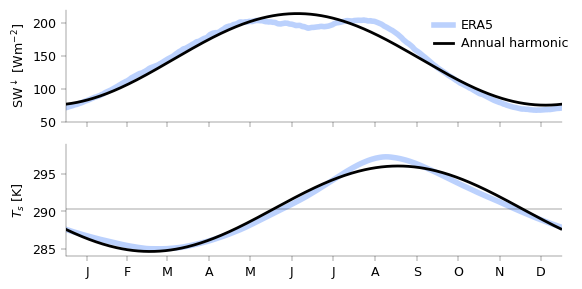

In [6]:
skip_direct = False
simulated_alpha=0.4
fig, ax = plt.subplots(2, 1, sharex=True)
fig_resize(fig, utils.width['one_col']*2, 4)
for key in ['simulated', 'direct']:
    for i, key2 in enumerate(['msnswrf', 'skt']):
        time_plot = np.arange(ds.time.size)
        if skip_direct and key == 'direct':
            time_plot = time_plot - 1000
        ax[i].plot(time_plot, ds_single[key2].sel(fit_method=key), color=style_map[key][0], label=style_map[key][2],
                   lw=style_map[key][3], alpha=simulated_alpha if key=='simulated' else 1)
        if key == 'simulated':
            var = float(xskillscore.r2(ds_single[key2].sel(fit_method='simulated'), ds_single[key2].sel(fit_method='direct'), dim='time'))
            print(f"Variance explained for {key2}: {var:.2f}")
ax[1].axhline(ds_single.skt.sel(fit_method='direct').mean(), color='k', lw=ax_linewidth)
ax[0].set_xlim(0, ds.time.size)
ax[0].legend(loc='upper right', bbox_to_anchor=(1.03, 1))
ax[0].set_xticks(*month_ticks)
ax[0].set_ylabel('$\\text{SW}^{\\downarrow}$ [Wm$^{-2}$]')
ax[1].set_ylabel('$T_s$ [K]')
update_fontsize(fig, 4.5)
ax[0].set_ylim(50, 220)
lims_temp_surf = [284, 299]
ax[1].set_ylim(lims_temp_surf)
plt.show()
# savefig(fig)

Variance explained for net_up_flux: 0.99
Variance explained for skt: 0.98


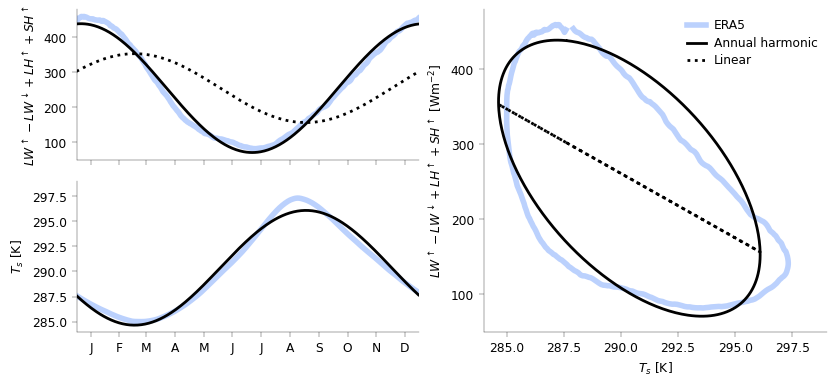

In [75]:
simulated_alpha = 0.4
skip_direct = False
skip_linear = False
fig = plt.figure(constrained_layout=True)
gs = fig.add_gridspec(2, 2)

ax = [fig.add_subplot(gs[0, 0])]
ax.append(fig.add_subplot(gs[1, 0], sharex=ax[0]))
ax.append(fig.add_subplot(gs[:, 1], sharey=ax[0]))  # span both rows in second column

ax[0].label_outer()  # hides x tick labels on top-left
fig_resize(fig, utils.width['two_col']*1.5, 2.2)
for key in ['simulated', 'direct']:
    for i, key2 in enumerate(['net_up_flux', 'skt']):
        time_plot = np.arange(ds.time.size)
        if skip_direct and key == 'direct':
            time_plot = time_plot - 1000
        ax[i].plot(time_plot, ds_single[key2].sel(fit_method=key), color=style_map[key][0], label=style_map[key][2],
                   lw=style_map[key][3], alpha=simulated_alpha if key=='simulated' else 1)
        if key == 'simulated':
            var = float(xskillscore.r2(ds_single[key2].sel(fit_method='simulated'), ds_single[key2].sel(fit_method='direct'), dim='time'))
            print(f"Variance explained for {key2}: {var:.2f}")
    ax[2].plot(ds_single['skt'].sel(fit_method=key), ds_single['net_up_flux'].sel(fit_method=key), color=style_map[key][0],
               label=style_map[key][2], lw=style_map[key][3], alpha=simulated_alpha if key=='simulated' else 1)

key = 'linear'
ax[0].plot(np.arange(ds.time.size)-skip_linear*1000, ds_single['net_up_flux'].sel(fit_method='linear'), color=style_map[key][0], label=style_map[key][2],
           lw=style_map[key][3], linestyle=style_map[key][1])
ax[2].plot(ds_single['skt'].sel(fit_method='direct')-skip_linear*1000, ds_single['net_up_flux'].sel(fit_method='linear'),
           color=style_map[key][0], label=style_map[key][2], lw=style_map[key][3], linestyle=style_map[key][1])
ax[0].set_xlim(0, ds.time.size)
lims_up_flux = [50, 480]
ax[0].set_ylim(lims_up_flux)
ax[0].set_xticks(*month_ticks)
ax[2].set_xticks(ax[1].get_yticks())
ax[1].set_ylim(lims_temp_surf)
ax[2].set_xlim(lims_temp_surf)
ax[2].legend(loc='upper right')
ax[0].set_ylabel('$LW^{\\uparrow}-LW^{\\downarrow} + LH^{\\uparrow} + SH^{\\uparrow}$')
ax[2].set_ylabel('$LW^{\\uparrow}-LW^{\\downarrow} + LH^{\\uparrow} + SH^{\\uparrow}$ [Wm$^{-2}$]')
ax[1].set_ylabel('$T_s$ [K]')
ax[2].set_xlabel('$T_s$ [K]')
update_fontsize(fig, 7.5)
# ax[0].set_ylabel('Net upward flux [Wm$^{-2}$]')
plt.show()
# savefig(fig)
#TODO: print lambda, lambda phase in both versions i.e. time shift and normal

In [2]:
small_grid = True
small_lat = slice(40, 0)
small_lon = slice(90, 150)
load_indiv_flux = False
files_fourier = sorted(glob(os.path.join(data_dir, "fourier_coef", "*.nc")))
if not load_indiv_flux:
    files_fourier = [file for file in files_fourier if 'ms' not in file]
var = {}
for i, file in tqdm(enumerate(files_fourier), total=len(files_fourier)):
    key = Path(file).stem
    if key == 'net_up_flux':
        var[key] = {'simulated': (-ds.mslhf - ds.msshf - ds.msnlwrf)}
    else:
        var[key] = {'simulated': ds[key]}
    if small_grid:
        var[key]['simulated'] = var[key]['simulated'].sel(latitude=small_lat, longitude=small_lon)
    var[key]['simulated'].load()

  0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
# Load in fourier coefficients
fourier_coef = {}
for key in ['amp', 'phase']:
    fourier_coef[key] = xr.merge([
        xr.open_dataset(f)[[key]].rename({key: Path(f).stem})
        for f in files_fourier
    ])
    if small_grid:
        fourier_coef[key] = fourier_coef[key].sel(latitude=small_lat, longitude=small_lon)
    fourier_coef[key].load()

In [4]:
# Compute annual harmonic
for i, key in tqdm(enumerate(fourier_coef['amp']), total=len(fourier_coef['amp'])):
    var[key]['direct'] = utils.fourier_series_xr(np.arange(ds.time.size), fourier_coef['amp'][key],
                                                 fourier_coef['phase'][key], pad_coefs_phase=True).astype('float32')

  0%|          | 0/2 [00:00<?, ?it/s]

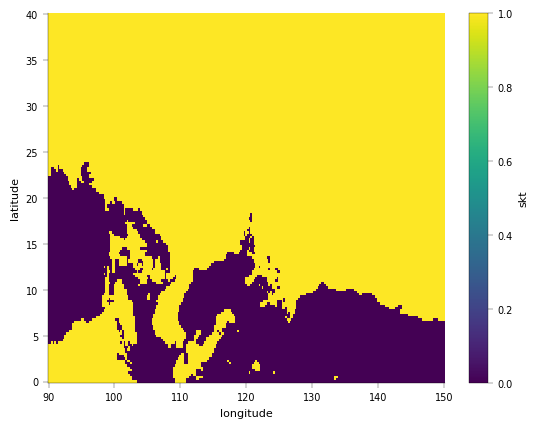

In [18]:
thresh_var_explained = 0.8
mask = xskillscore.r2(var['skt']['simulated'], var['skt']['direct'], dim='time') > 0.8
mask.plot()

In [6]:
if load_indiv_flux:
    # Sanity check that sum of direct harmonics equals direct harmonic of sum
    np.abs((-var['mslhf']['direct'] - var['msshf']['direct'] - var['msnlwrf']['direct']) - var['net_up_flux'][
        'direct']).max()

In [7]:
with tqdm(total=2) as pbar:
    var['rh_atm'] = {'simulated': get_rh(ds.d2m, ds.t2m, ds.sp)}
    if small_grid:
        var['rh_atm']['simulated'] = var['rh_atm']['simulated'].sel(latitude=small_lat, longitude=small_lon)
    var['rh_atm']['simulated'].load()
    pbar.update(1)
    var['w_atm'] = {'simulated': np.sqrt(ds['u10'] ** 2 + ds['v10'] ** 2)}
    if small_grid:
        var['w_atm']['simulated'] = var['w_atm']['simulated'].sel(latitude=small_lat, longitude=small_lon)
    var['w_atm']['simulated'].load()
    pbar.update(1)

  0%|          | 0/2 [00:00<?, ?it/s]

In [8]:
fit_params = xr.open_mfdataset(f'{data_dir}/empirical_fitting/*.nc')
if small_grid:
    fit_params = fit_params.sel(latitude=small_lat, longitude=small_lon)
fit_params = fit_params.load()

In [9]:
# Sanity check that sum of fit parameters equal fit parameters of sum
(np.abs((-fit_params['mslhf'] - fit_params['msshf'] - fit_params['msnlwrf']) -
        fit_params['net_up_flux']).sel(fit_method='linear_phase')).quantile(0.95, dim=['longitude', 'latitude'])

<xarray.DataArray (deg: 6)> Size: 48B
array([6.38961792e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.90734863e-06, 9.76562500e-04])
Coordinates:
  * deg       (deg) <U5 120B 'phase' 'cos' 'sin' '2' '1' '0'
    quantile  float64 8B 0.95

In [10]:
var_to_fit = ['net_up_flux', 'rh_atm', 'w_atm']
with tqdm(total=2 * len(var_to_fit)) as pbar:
    for key in var_to_fit:
        for key2 in ['linear', 'linear_phase']:
            # Use actual skt for variable e.g. wind and rh but annual harmonic for the fluxes
            var[key][key2] = utils.polyval_phase_xr(fit_params[key].sel(fit_method=key2),
                                                    var['skt']['simulated' if 'atm' in key2 else 'direct']).astype(
                'float32')
            pbar.update(1)

  0%|          | 0/6 [00:00<?, ?it/s]

In [100]:
flux_individual_error = {}
for i, key in tqdm(enumerate(['mslhf', 'msshf', 'msnlwrf']), total=3):
    var_use_linear = utils.polyval_phase_xr(fit_params[key].sel(fit_method='linear'), var['skt']['direct']).astype(
        'float32')
    var_use_phase = utils.polyval_phase_xr(fit_params[key].sel(fit_method='linear_phase'), var['skt']['direct']).astype(
        'float32')
    # this assumes var_use_phase is basically exact so error is difference between phase and linear
    # In theory phase is exact because is possible to exactly match the annual harmonic with linear_phase. Only differs because of
    # exact method used to obtain lambda_phase
    flux_individual_error[key] = np.abs(var_use_phase - var_use_linear).mean(dim='time')
flux_individual_error = xr.concat(
    [flux_individual_error[key] for key in list(flux_individual_error.keys())],
    dim=xr.DataArray(list(flux_individual_error.keys()), dims="flux", name="flux"),
)

  0%|          | 0/3 [00:00<?, ?it/s]

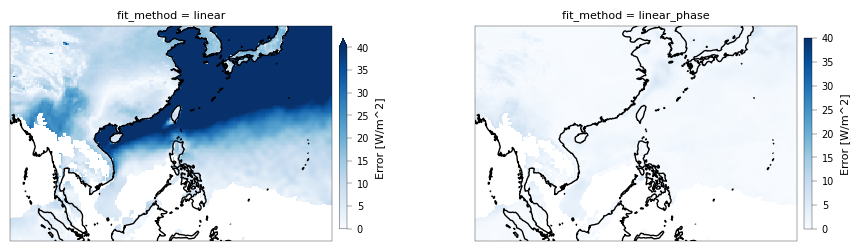

In [168]:
key = 'net_up_flux'
fig, ax = plt.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})
fig_resize(fig, utils.width['two_col'] * 2)
np.abs(var[key]['direct'] - var[key]['linear']).mean(dim='time').where(mask).plot(
    vmin=0, vmax=40, cmap='Blues', ax=ax[0],
    cbar_kwargs={"shrink": 0.3, "aspect": 25, "pad": 0.02, 'label': 'Error [W/m^2]'})
(np.abs(var[key]['direct'] - var[key]['linear_phase']).mean(dim='time')).where(mask).plot(
    vmin=0, vmax=40, cmap='Blues', ax=ax[1],
    cbar_kwargs={"shrink": 0.3, "aspect": 25, "pad": 0.02, 'label': 'Error [W/m^2]'})
ax[0].coastlines()
ax[1].coastlines()
plt.show()

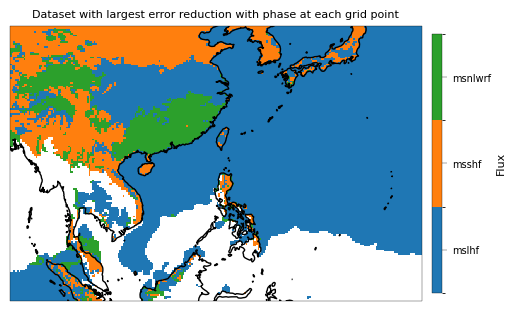

In [173]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
cmap = mcolors.ListedColormap(["tab:blue", "tab:orange", "tab:green"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
im = flux_individual_error.argmax(dim='flux').where(mask).plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=True, cbar_kwargs={"shrink": 0.7, "aspect": 25, "pad": 0.02, 'label': 'Flux'}
)
cbar = im.colorbar
cbar.set_ticks(range(len(flux_individual_error.flux)))
cbar.set_ticklabels(flux_individual_error.flux.values)
ax.coastlines()

ax.set_title("Dataset with largest error reduction with phase at each grid point")
plt.show()

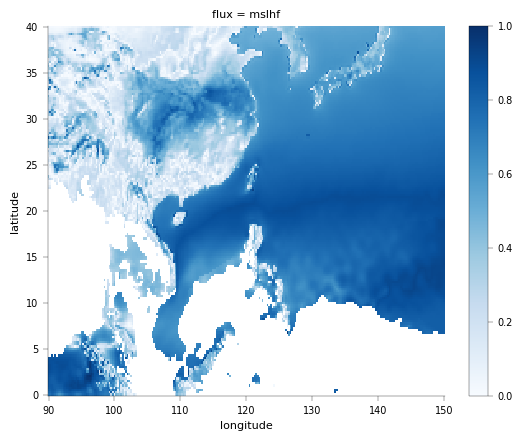

In [145]:
error_frac = flux_individual_error.sel(flux='mslhf') / flux_individual_error.sum(dim='flux')
error_frac.where(mask).plot(cmap='Blues', vmin=0, vmax=1)
plt.show()

In [148]:
var_individual_error = {}
for i, key in tqdm(enumerate(['w_atm', 'rh_atm']), total=2):
    var_use_linear = utils.polyval_phase_xr(fit_params[key].sel(fit_method='linear'), var['skt']['direct']).astype(
        'float32')
    var_use_phase = utils.polyval_phase_xr(fit_params[key].sel(fit_method='linear_phase'), var['skt']['direct']).astype(
        'float32')
    # this assumes var_use_phase is basically exact so error is difference between phase and linear
    # In theory phase is exact because is possible to exactly match the annual harmonic with linear_phase. Only differs because of
    # exact method used to obtain lambda_phase
    var_individual_error[key] = np.abs(var_use_phase - var_use_linear).mean(dim='time')
var_individual_error = xr.concat(
    [var_individual_error[key] for key in list(var_individual_error.keys())],
    dim=xr.DataArray(list(var_individual_error.keys()), dims="var", name="var"),
)

  0%|          | 0/2 [00:00<?, ?it/s]

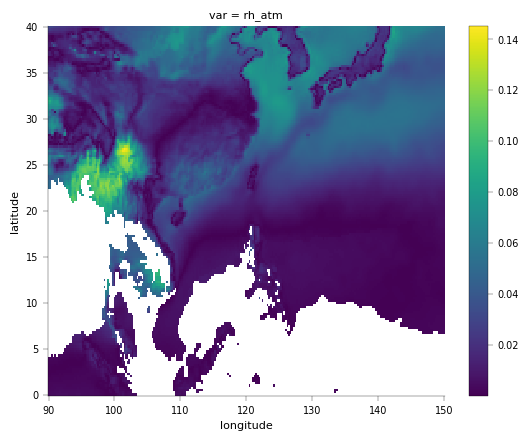

In [174]:
var_individual_error.sel(var='rh_atm').where(mask).plot()

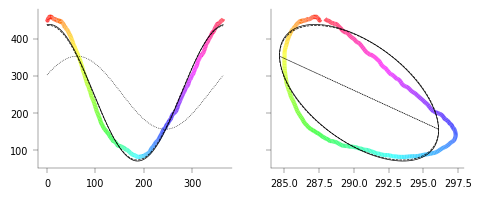

In [189]:
style_map = utils.style_map
style_map['direct'] = ['k', '-', 'Annual harmonic']
time_plot = np.arange(ds.time.size)
plot_lat = 38
plot_lon = 150
# plot_lon = 90
# plot_lat = 26
# plot_lon = 101
fig, ax = plt.subplots(1, 2, sharey=True)
fig_resize(fig, utils.width['two_col'])
im = colored_line(time_plot,
                  var['net_up_flux']['simulated'].sel(latitude=plot_lat, longitude=plot_lon), c=time_plot,
                  cmap='hsv', ax=ax[0], lw=3, alpha=0.7)
for key in ['direct', 'linear', 'linear_phase']:
    ax[0].plot(time_plot, var['net_up_flux'][key].sel(latitude=plot_lat, longitude=plot_lon), color='k',
               label=utils.style_map[key][2], linestyle=utils.style_map[key][1])

im = colored_line(var['skt']['simulated'].sel(latitude=plot_lat, longitude=plot_lon),
                  var['net_up_flux']['simulated'].sel(latitude=plot_lat, longitude=plot_lon), c=time_plot,
                  cmap='hsv', ax=ax[1], lw=3, alpha=0.7)
# # im = ax[1].scatter(temp_anom_fit.isel(lat=plot_lat_ind, depth=plot_depth_ind).sel(fit_method='simulated'),
# #                    surf_flux_up.net.isel(lat=plot_lat_ind, depth=plot_depth_ind).sel(fit_method='simulated'), c=ds.time,
# #                    cmap='hsv')
for key in ['direct', 'linear', 'linear_phase']:
    ax[1].plot(var['skt']['direct'].sel(latitude=plot_lat, longitude=plot_lon),
               var['net_up_flux'][key].sel(latitude=plot_lat, longitude=plot_lon), color='k',
               linestyle=utils.style_map[key][1], label=utils.style_map[key][1])
#
# cbar = fig.colorbar(im, ax=ax[1], aspect=100, pad=0.03, fraction=0.01)
# cbar.ax.invert_yaxis()
# cbar.ax.set_yticks(*utils.month_ticks)
# ax[0].set_ylabel(
#     '$\Gamma^{\\uparrow}$ [Wm$^{-2}$]')
# # ax[0].set_ylabel(
# #     '$LW^{\\uparrow}-LW^{\\downarrow}+LH^{\\uparrow}+SH^{\\uparrow}$ [Wm$^{-2}$]')
# ax[1].set_xlabel('$T_s - \overline{T}_s$ [K]')
# # ax[1].set_xlim(-np.ceil(np.abs(t_surf_anom[plot_lat_ind]).max()), np.ceil(np.abs(t_surf_anom[plot_lat_ind]).max()))
# # ax[1].set_ylim(np.floor(gamma['simulated'][plot_lat_ind].min()), np.ceil(gamma['simulated'][plot_lat_ind].max()))
# update_linewidth(fig)
# ax[0].legend(handlelength=utils.leg_handlelength, loc='lower right', bbox_to_anchor=(1.05, 0))
# ax[0].set_xlim(ax_lims_time)
# ax[0].set_xticks(*utils.month_ticks)
# label_subplots(fig, ax)
# update_fontsize(fig)
# plt.show()
# print(f"{ds.depth.values[plot_depth_ind]:.0f}m")
# print(f"{ds.lat.values[plot_lat_ind]:.1f} deg")
#
# # Print interpretation of variables
# var = surf_flux_up_params['net'].sel(fit_method='linear_phase').isel(depth=plot_depth_ind, lat=plot_lat_ind)
# var_time = phase_coef_conv_xr(var)
# print(f"Normal form", {key: np.round(float(var.sel(deg=key)), 2) for key in var.deg.values})
# print(f"Time form", {key: np.round(float(var_time.sel(deg=key)), 2) for key in var_time.deg.values})

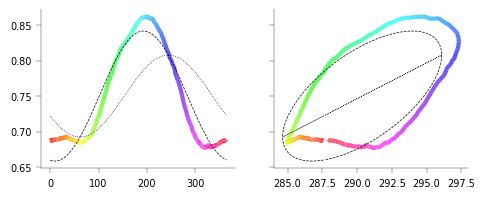

In [190]:
key_use = 'rh_atm'
fig, ax = plt.subplots(1, 2, sharey=True)
fig_resize(fig, utils.width['two_col'])
im = colored_line(time_plot,
                  var[key_use]['simulated'].sel(latitude=plot_lat, longitude=plot_lon), c=time_plot,
                  cmap='hsv', ax=ax[0], lw=3, alpha=0.7)
for key in ['linear', 'linear_phase']:
    ax[0].plot(time_plot, var[key_use][key].sel(latitude=plot_lat, longitude=plot_lon), color='k',
               label=utils.style_map[key][2], linestyle=utils.style_map[key][1])

im = colored_line(var['skt']['simulated'].sel(latitude=plot_lat, longitude=plot_lon),
                  var[key_use]['simulated'].sel(latitude=plot_lat, longitude=plot_lon), c=time_plot,
                  cmap='hsv', ax=ax[1], lw=3, alpha=0.7)
for key in ['linear', 'linear_phase']:
    ax[1].plot(var['skt']['direct'].sel(latitude=plot_lat, longitude=plot_lon),
               var[key_use][key].sel(latitude=plot_lat, longitude=plot_lon), color='k',
               linestyle=utils.style_map[key][1], label=utils.style_map[key][1])